# Семинар 13

# Stochastic Optimization 4: Lion and AdaHessian

[SignSGD](https://arxiv.org/abs/1802.04434)

[Lion Paper](https://arxiv.org/pdf/2302.06675)

[AdaHessian Paper](https://arxiv.org/pdf/2006.00719)

In [1]:
import numpy as np
import copy
import time
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

In [2]:
import torch
from torch import nn
from torch.optim import Optimizer
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [ ]:
transform=torchvision.transforms.Compose([
        torchvision.transforms.Resize((224,224)),
        torchvision.transforms.ToTensor(),
    ])

train_dataset = datasets.CIFAR10(root='./data',
                            train=True, download=True,
                            transform=transform)
test_dataset = datasets.CIFAR10(root='./data',
                           train=False, download=True,
                           transform=transform)


In [ ]:
import torchvision
import torch


train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

means = []
stdevs = []
for X, _ in train_dataloader:
    # Dimensions 0,2,3 are respectively the batch, height and width dimensions
    means.append(X.mean(dim=(0,2,3)))
    stdevs.append(X.std(dim=(0,2,3)))

mean = torch.stack(means, dim=0).mean(dim=0)
stdev = torch.stack(stdevs, dim=0).mean(dim=0)


In [ ]:
train_transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize((224,224)),
        torchvision.transforms.AutoAugment(policy=torchvision.transforms.AutoAugmentPolicy.CIFAR10),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean, stdev)
    ])

train_dataset = datasets.CIFAR10(root='./data',
                            train=True, download=True,
                            transform=train_transforms)

valid_transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize((224,224)),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean, stdev)
    ])

test_dataset = datasets.CIFAR10(root='./data',
                            train=False, download=True,
                            transform=valid_transforms)

In [ ]:
num_gpus = torch.cuda.device_count()

train_dataloader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size=128,
                                               shuffle=True,
                                               num_workers=2*num_gpus,
                                               pin_memory=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset,
                                              batch_size=256,
                                              shuffle=False,
                                              num_workers=2*num_gpus,
                                              pin_memory=True)


In [ ]:
def get_net():
    torch.manual_seed(121)
    resnet = torchvision.models.resnet34(pretrained=True)

    # Substitute the FC output layer
    resnet.fc = torch.nn.Linear(resnet.fc.in_features, 10)
    torch.nn.init.xavier_uniform_(resnet.fc.weight)
    return resnet

In [ ]:
import time

def train(net, train_dataloader, valid_dataloader,
          criterion, optimizer, scheduler=None,
          epochs=10, device='cpu', checkpoint_epochs=10,
         create_graph=False):
    start = time.time()
    print(f'Training for {epochs} epochs on {device}')
    logs = []

    for epoch in range(1,epochs+1):
        print(f"Epoch {epoch}/{epochs}")

        net.train()  # put network in train mode for Dropout and Batch Normalization
        train_loss = torch.tensor(0., device=device)  # loss and accuracy tensors are on the GPU to avoid data transfers
        train_accuracy = torch.tensor(0., device=device)
        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)
            preds = net(X)
            loss = criterion(preds, y)

            optimizer.zero_grad()
            loss.backward(create_graph=create_graph)
            optimizer.step()

            with torch.no_grad():
                train_loss += loss * train_dataloader.batch_size
                train_accuracy += (torch.argmax(preds, dim=1) == y).sum()

        if valid_dataloader is not None:
            net.eval()  # put network in train mode for Dropout and Batch Normalization
            valid_loss = torch.tensor(0., device=device)
            valid_accuracy = torch.tensor(0., device=device)
            with torch.no_grad():
                for X, y in valid_dataloader:
                    X = X.to(device)
                    y = y.to(device)
                    preds = net(X)
                    loss = criterion(preds, y)

                    valid_loss += loss * valid_dataloader.batch_size
                    valid_accuracy += (torch.argmax(preds, dim=1) == y).sum()

        if scheduler is not None:
            scheduler.step()

        print(f'Training loss: {train_loss/len(train_dataloader.dataset):.2f}')
        print(f'Training accuracy: {100*train_accuracy/len(train_dataloader.dataset):.2f}')

        if valid_dataloader is not None:
            print(f'Valid loss: {valid_loss/len(valid_dataloader.dataset):.2f}')
            print(f'Valid accuracy: {100*valid_accuracy/len(valid_dataloader.dataset):.2f}')
            logs.append([train_loss/len(train_dataloader.dataset),
                        100*train_accuracy/len(train_dataloader.dataset),
                        valid_loss/len(valid_dataloader.dataset),
                         100*valid_accuracy/len(valid_dataloader.dataset)])
        print(f'Training loss: {time.time()-start:.1f}')
        if epoch%checkpoint_epochs==0:
            torch.save({
                'epoch': epoch,
                'state_dict': net.state_dict(),
                'optimizer': optimizer.state_dict(),
            }, './checkpoint.pth.tar')

        print()

    end = time.time()
    print(f'Total training time: {end-start:.1f} seconds')
    return net, logs

In [ ]:
from typing import Tuple, Optional, Callable

import torch
from torch.optim.optimizer import Optimizer


def exists(val):
    return val is not None


def update_fn(p, grad, exp_avg, lr, wd, beta1, beta2):

    p.data.mul_(1 - lr * wd)

    update = exp_avg.clone().mul_(beta1).add(grad, alpha = 1 - beta1).sign_()
    p.add_(update, alpha = -lr)

    exp_avg.mul_(beta2).add_(grad, alpha = 1 - beta2)


class Lion(Optimizer):
    def __init__(
        self,
        params,
        lr: float = 1e-4,
        betas: Tuple[float, float] = (0.9, 0.99),
        weight_decay: float = 0.0,
        use_triton: bool = False
    ):
        assert lr > 0.
        assert all([0. <= beta <= 1. for beta in betas])

        defaults = dict(
            lr = lr,
            betas = betas,
            weight_decay = weight_decay
        )
        super().__init__(params, defaults)
        self.update_fn = update_fn


    @torch.no_grad()
    def step(
        self,
        closure: Optional[Callable] = None
    ):

        loss = None
        if exists(closure):
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in filter(lambda p: exists(p.grad), group['params']):

                grad, lr, wd, beta1, beta2, state = p.grad, group['lr'], group['weight_decay'], *group['betas'], self.state[p]


                if len(state) == 0:
                    state['exp_avg'] = torch.zeros_like(p)

                exp_avg = state['exp_avg']

                self.update_fn(p, grad, exp_avg, lr, wd, beta1, beta2)

        return loss

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
lr, weight_decay, epochs = 1e-5, 0, 30
net = get_net().to(device)

params_1x = [param for name, param in net.named_parameters() if 'fc' not in str(name)]
optimizer = torch.optim.Adam([{'params':params_1x},
                              {'params': net.fc.parameters(),
                               'lr': lr*10}],
                             lr=lr, weight_decay=weight_decay)
net, logs_adam = train(net, train_dataloader, test_dataloader,
            criterion, optimizer, None, epochs, device)

In [ ]:
lr, weight_decay, epochs = 1e-5, 1e-2, 30
net = get_net().to(device)

params_1x = [param for name, param in net.named_parameters() if 'fc' not in str(name)]
optimizer = torch.optim.AdamW([{'params':params_1x}, 
                               {'params': net.fc.parameters(), 
                                'lr': lr*10}], lr=lr)
net, logs_adamW = train(net, train_dataloader, test_dataloader, criterion, optimizer, None, epochs, device)

In [ ]:
lr, weight_decay, epochs = 1e-5, 0, 30
net = get_net().to(device)

params_1x = [param for name, param in net.named_parameters() if 'fc' not in str(name)]
optimizer = Lion([{'params':params_1x}, {'params': net.fc.parameters(), 'lr': lr*10}], lr=lr)
net, logs_lion = train(net, train_dataloader, test_dataloader, criterion, optimizer, None, epochs, device)

In [ ]:
!pip install torch_optimizer

In [ ]:
import torch_optimizer as optim
lr, weight_decay, epochs = 1e-2, 0, 30
net = get_net().to(device)

params_1x = [param for name, param in net.named_parameters() if 'fc' not in str(name)]
optimizer = optim.Adahessian([{'params':params_1x}, {'params': net.fc.parameters(), 'lr': lr*10}], lr=lr, weight_decay=weight_decay)
net, logs_adahessian = train(net, train_dataloader, test_dataloader, criterion, optimizer, None, epochs, device, create_graph=True)

In [ ]:
# logs = {"Adam": logs_adam,
#        "AdamW": logs_adamW,
#         "Lion": logs_lion,
#         "adahessian": logs_adahessian
#        }

In [ ]:
# import pickle
# with open("logs.pickle", "wb") as f:
#     pickle.dump(logs, f)

In [3]:
import pickle
with open("logs.pickle", "rb") as f:
    logs = pickle.load(f)

<Figure size 2160x1440 with 0 Axes>

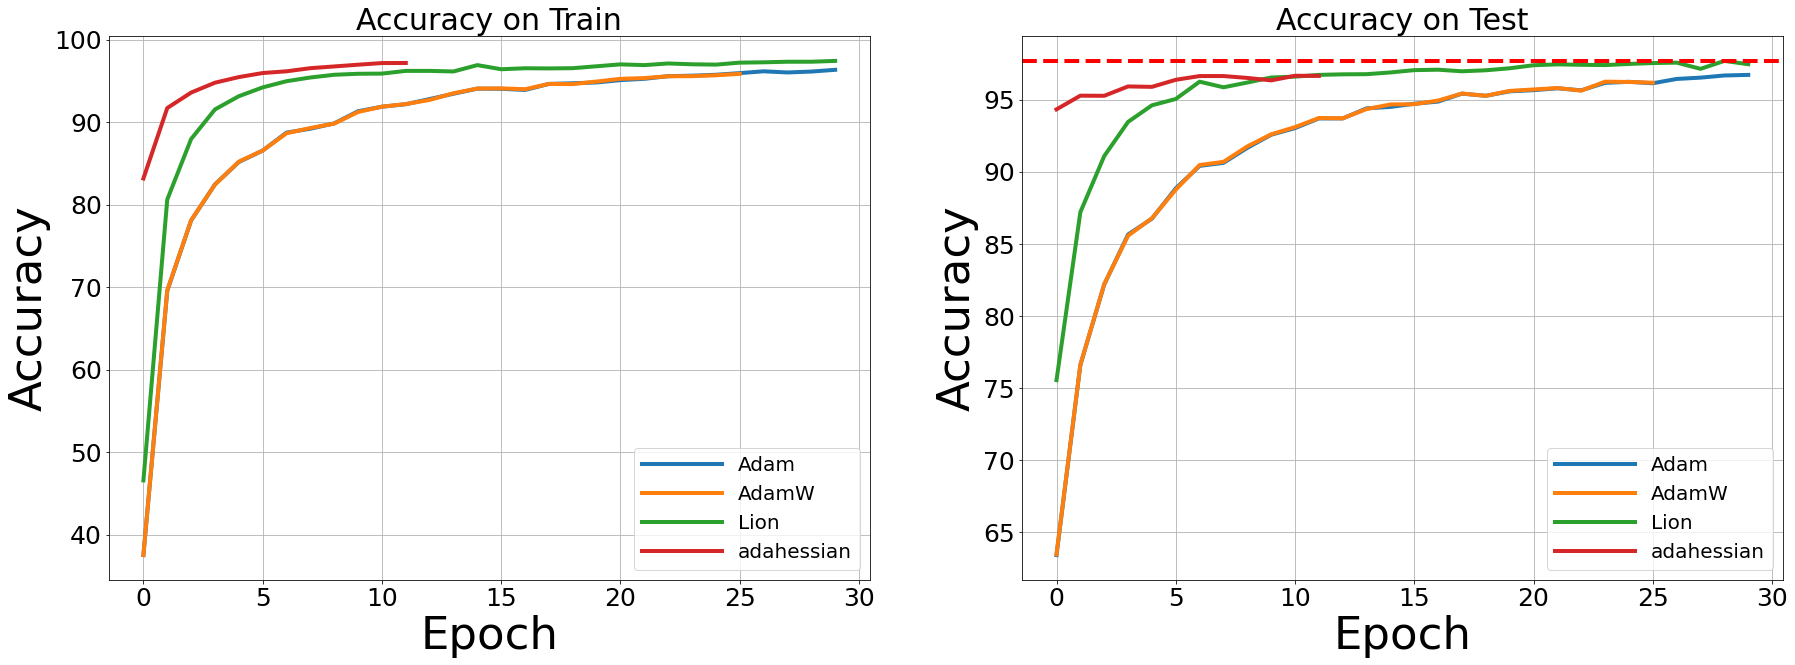

In [5]:
%matplotlib inline
plt.figure(figsize=(30, 20))
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
label = None
y_min = None
for label, vals in logs.items():
    ax[0].plot([log[1] for log in vals], label=label)
    ax[1].plot([log[3] for log in vals], label=label)
    if y_min is None or y_min < max([log[3] for log in vals]):
        y_min = max([log[3] for log in vals])
ax[0].legend()
ax[0].set_ylabel("Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_title("Accuracy on Train")
ax[0].grid()
ax[1].legend()
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_title("Accuracy on Test")
ax[1].axhline(y=y_min, color='r', linestyle='--')
ax[1].grid()

<Figure size 2160x1440 with 0 Axes>

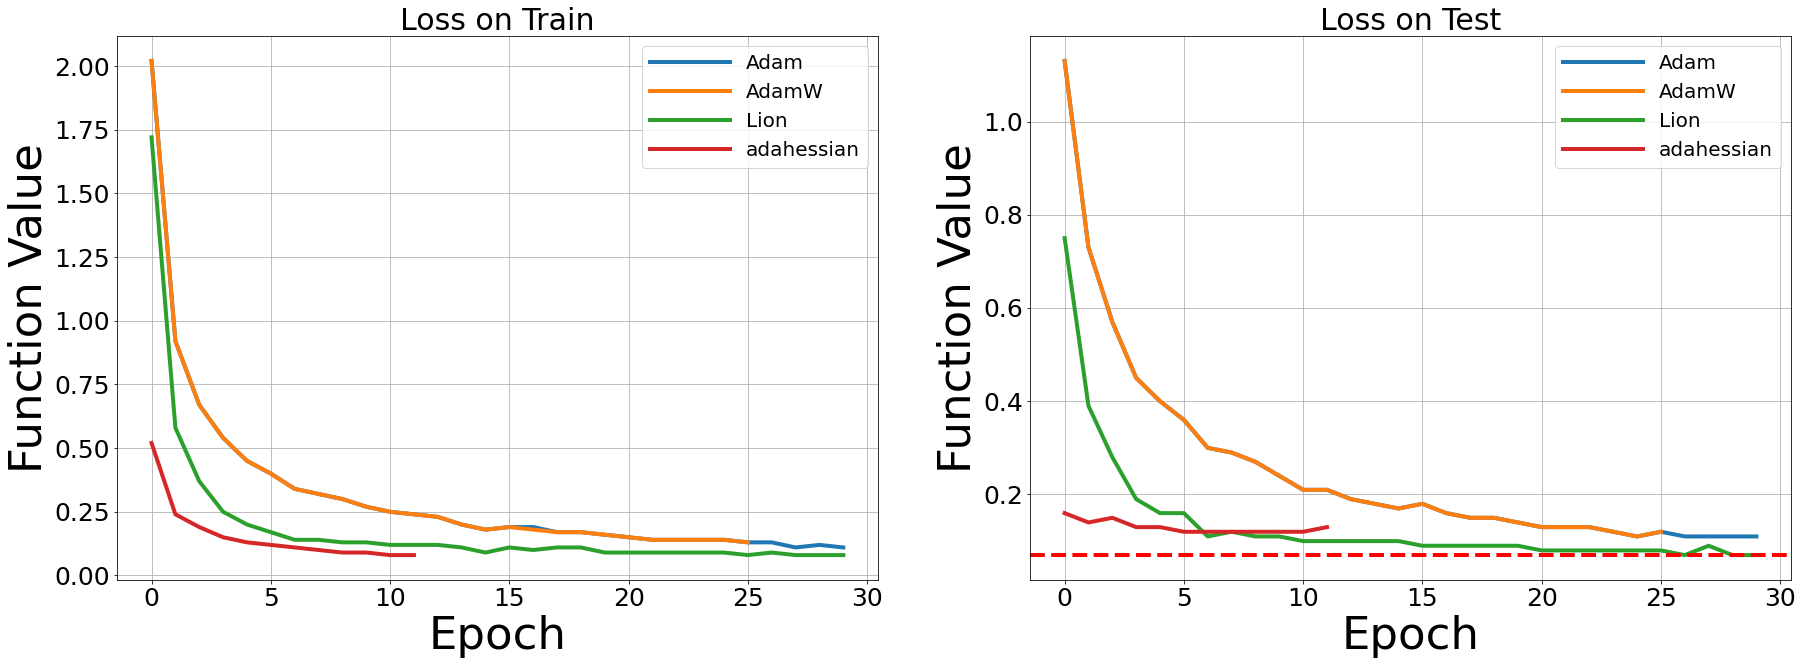

In [5]:
%matplotlib inline
plt.figure(figsize=(30, 20))
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
label = None
y_min = None
for label, vals in logs.items():
    ax[0].plot([log[0] for log in vals], label=label)
    ax[1].plot([log[2] for log in vals], label=label)
    if y_min is None or y_min > min([log[2] for log in vals]):
        y_min = min([log[2] for log in vals])
ax[0].legend()
ax[0].set_ylabel("Function Value")
ax[0].set_xlabel("Epoch")
ax[0].set_title("Loss on Train")
ax[0].grid()
ax[1].legend()
ax[1].set_ylabel("Function Value")
ax[1].set_xlabel("Epoch")
ax[1].set_title("Loss on Test")
ax[1].axhline(y=y_min, color='r', linestyle='--')
ax[1].grid()